# Full Dataset Pandas Benchmark
Runs the two remaining MapReduce candidates (Popular Routes and Weather x Route) on the full 14.8M row dataset and writes results to `metrics.json` for comparison against Spark.

In [ ]:
import pandas as pd
import time
import json
import psutil
import os
from pathlib import Path

FULL_CSV_PATH = Path("../data/processed/trips_clean.csv") 
METRICS_PATH  = Path("../results/metrics.json")

print("=" * 50)
print("PANDAS FULL DATASET BENCHMARK")
print("=" * 50)

print("\nLoading full dataset...")
t_load_start = time.perf_counter()

df = pd.read_csv(FULL_CSV_PATH, dtype={"ride_id": str, "start_station_id": str, "end_station_id": str})
df["started_at"] = pd.to_datetime(df["started_at"], utc=True)
df["ended_at"]   = pd.to_datetime(df["ended_at"],   utc=True)
df["ride_length_minutes"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

load_s = time.perf_counter() - t_load_start
print(f"Rows loaded : {len(df):,}")
print(f"Elapsed     : {load_s:.4f}s")

PANDAS FULL DATASET BENCHMARK

Loading full dataset...
Rows loaded : 14,804,463
Elapsed     : 112.7708s


In [ ]:
full_timings = {"load": round(load_s, 4)}

print("\n===== Popular Routes (MR Candidate 1) =====")
t0 = time.perf_counter()

routes = (
    df.dropna(subset=["start_station_name", "end_station_name"])
      .query("start_station_name != '' and end_station_name != ''")
      .groupby(["start_station_name", "end_station_name"], sort=False)
      .size()
      .reset_index(name="route_count")
      .sort_values("route_count", ascending=False)
)

routes_s = time.perf_counter() - t0
full_timings["popular_routes_query"] = round(routes_s, 4)

print(f"Query elapsed       : {routes_s:.4f}s")
print(f"Unique routes found : {len(routes):,}")
display(routes.head(10))

print("\n===== Weather x Route (MR Candidate 3) =====")
t0 = time.perf_counter()

weather_routes = (
    df.dropna(subset=["start_station_name", "end_station_name"])
      .query("start_station_name != '' and end_station_name != ''")
      .assign(
          conditions=lambda x: x["PRCP"].apply(lambda p: "rainy" if p > 0 else "dry"),
          temp_band=lambda x: pd.cut(
              x["TMAX"],
              bins=[0, 50, 65, 80, 120],
              labels=["Cold (<50F)", "Mild (50-65F)", "Warm (65-80F)", "Hot (>80F)"]
          )
      )
      .groupby(["conditions", "temp_band", "start_station_name", "end_station_name"], observed=True)
      .agg(
          route_count=("ride_id", "count"),
          avg_duration_minutes=("ride_length_minutes", "mean"),
          avg_precipitation=("PRCP", "mean"),
      )
      .round(2)
      .reset_index()
      .sort_values("route_count", ascending=False)
)

weather_s = time.perf_counter() - t0
full_timings["weather_routes_query"] = round(weather_s, 4)

print(f"Query elapsed : {weather_s:.4f}s")
display(weather_routes.head(10))

memory_mb = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

print("\n" + "=" * 50)
print("FULL DATASET SUMMARY")
print("=" * 50)
print(f"  {'Rows processed':<38} {len(df):,}")
print(f"  {'Load + preprocess':<38} {load_s:.4f}s")
print(f"  {'Popular routes (query only)':<38} {routes_s:.4f}s")
print(f"  {'Weather x route (query only)':<38} {weather_s:.4f}s")
print(f"  {'Peak memory (RSS)':<38} {memory_mb:.2f} MB")
print("=" * 50)

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
existing = {}
if METRICS_PATH.exists():
    try:
        existing = json.loads(METRICS_PATH.read_text())
    except json.JSONDecodeError:
        pass

existing["pandas_full_benchmark"] = {
    "rows"            : len(df),
    "load_seconds"    : round(load_s, 4),
    "queries"         : {
        "popular_routes_query" : round(routes_s, 4),
        "weather_routes_query" : round(weather_s, 4),
    },
    "memory_usage_mb" : round(memory_mb, 2),
}
METRICS_PATH.write_text(json.dumps(existing, indent=4))
print(f"\nMetrics written to: {METRICS_PATH.resolve()}")


===== Popular Routes (MR Candidate 1) =====
Query elapsed       : 33.5838s
Unique routes found : 231,669


,start_station_name,end_station_name,route_count
3340,Streeter Dr & Grand Ave,Streeter Dr & Grand Ave,31910
490,Michigan Ave & Oak St,Michigan Ave & Oak St,16245
115,Millennium Park,Millennium Park,15824
12996,Ellis Ave & 60th St,Ellis Ave & 55th St,12611
13111,Lake Shore Dr & Monroe St,Lake Shore Dr & Monroe St,11529
20562,Ellis Ave & 60th St,University Ave & 57th St,11401
12995,Ellis Ave & 55th St,Ellis Ave & 60th St,11393
157,Indiana Ave & Roosevelt Rd,Indiana Ave & Roosevelt Rd,10937
3446,Theater on the Lake,Theater on the Lake,10882
154837,DuSable Lake Shore Dr & Monroe St,DuSable Lake Shore Dr & Monroe St,10842



===== Weather x Route (MR Candidate 3) =====
Query elapsed : 64.8385s


,conditions,temp_band,start_station_name,end_station_name,route_count,avg_duration_minutes,avg_precipitation
522443,dry,Hot (>80F),Streeter Dr & Grand Ave,Streeter Dr & Grand Ave,14888,45.18,0.0
476653,dry,Hot (>80F),Michigan Ave & Oak St,Michigan Ave & Oak St,7707,48.49,0.0
346336,dry,Warm (65-80F),Streeter Dr & Grand Ave,Streeter Dr & Grand Ave,7028,44.38,0.0
478964,dry,Hot (>80F),Millennium Park,Millennium Park,6635,48.20,0.0
523248,dry,Hot (>80F),Theater on the Lake,Theater on the Lake,5127,41.63,0.0
422961,dry,Hot (>80F),DuSable Lake Shore Dr & Monroe St,DuSable Lake Shore Dr & Monroe St,4700,35.85,0.0
445126,dry,Hot (>80F),Indiana Ave & Roosevelt Rd,Indiana Ave & Roosevelt Rd,4674,48.65,0.0
431161,dry,Hot (>80F),Fort Dearborn Dr & 31st St,Fort Dearborn Dr & 31st St,4347,64.82,0.0
380341,dry,Hot (>80F),Buckingham Fountain,Buckingham Fountain,4256,64.94,0.0
455473,dry,Hot (>80F),Lake Shore Dr & Monroe St,Lake Shore Dr & Monroe St,4244,48.03,0.0



FULL DATASET SUMMARY
  Rows processed                         14,804,463
  Load + preprocess                      112.7708s
  Popular routes (query only)            33.5838s
  Weather x route (query only)           64.8385s
  Peak memory (RSS)                      1412.98 MB

Metrics written to: C:\Users\imonl\BigData\Cyclistic_Data\results\metrics.json


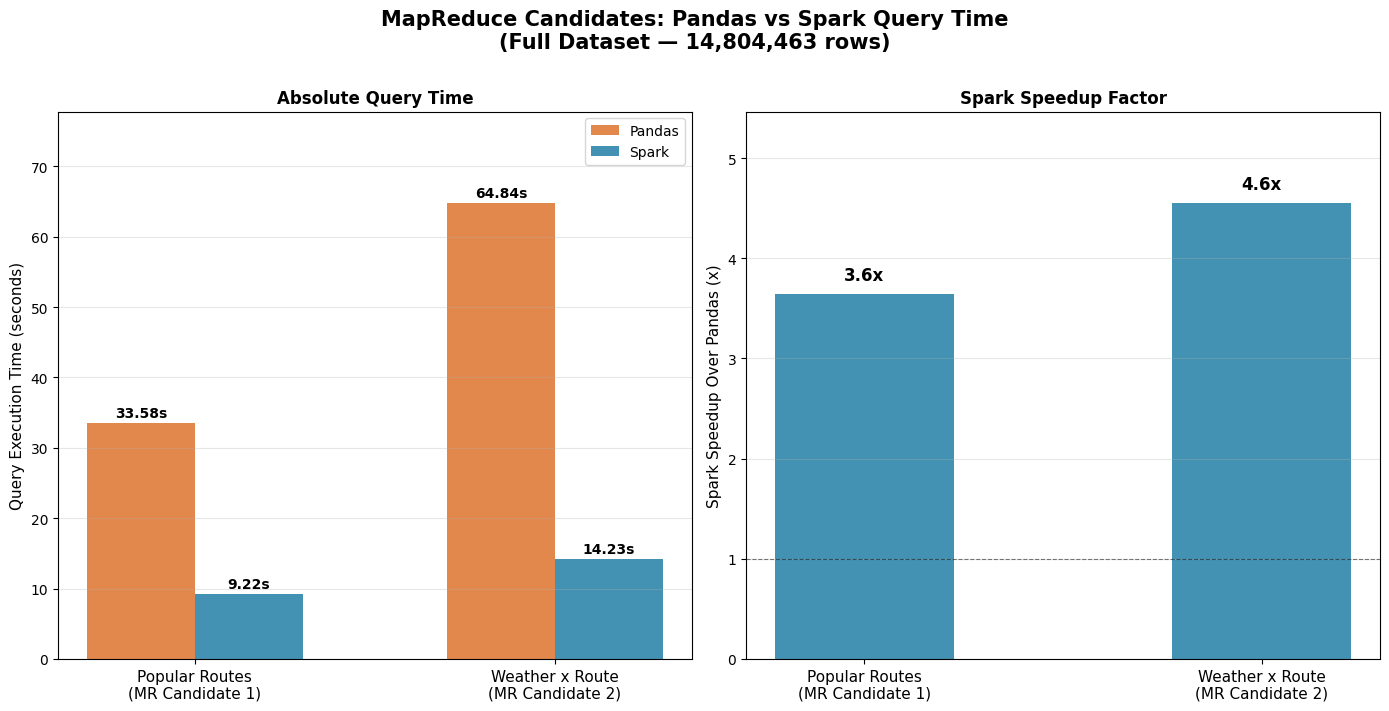


Speedup summary (from metrics.json):
  Popular Routes         Pandas: 33.58s   Spark: 9.22s   Speedup: 3.6x
  Weather x Route        Pandas: 64.84s   Spark: 14.23s   Speedup: 4.6x


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = json.loads(METRICS_PATH.read_text())

spark_routes  = metrics["spark_analysis"]["steps"]["popular_routes_mapreduce_1"]
spark_weather = metrics["spark_analysis"]["steps"]["weather_routes_mapreduce_2"]

pandas_routes  = metrics["pandas_full_benchmark"]["queries"]["popular_routes_query"]
pandas_weather = metrics["pandas_full_benchmark"]["queries"]["weather_routes_query"]

pandas_times = [pandas_routes,  pandas_weather]
spark_times  = [spark_routes,   spark_weather]
speedups     = [p / s for p, s in zip(pandas_times, spark_times)]

labels    = ["Popular Routes\n(MR Candidate 1)", "Weather x Route\n(MR Candidate 2)"]
x         = np.arange(len(labels))
bar_width = 0.3

COLOUR_PANDAS = "#E07B39"
COLOUR_SPARK  = "#2E86AB"

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "MapReduce Candidates: Pandas vs Spark Query Time\n(Full Dataset — 14,804,463 rows)",
    fontsize=15, fontweight="bold", y=1.01
)

ax = axes[0]
b1 = ax.bar(x - bar_width / 2, pandas_times, bar_width, label="Pandas", color=COLOUR_PANDAS, alpha=0.9)
b2 = ax.bar(x + bar_width / 2, spark_times,  bar_width, label="Spark",  color=COLOUR_SPARK,  alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.2f}s",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Query Execution Time (seconds)", fontsize=11)
ax.set_title("Absolute Query Time", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(pandas_times) * 1.2)

ax2 = axes[1]
bars = ax2.bar(x, speedups, bar_width * 1.5, color=COLOUR_SPARK, alpha=0.9)

for bar, s in zip(bars, speedups):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{s:.1f}x",
             ha="center", va="bottom", fontsize=12, fontweight="bold")

ax2.axhline(1, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylabel("Spark Speedup Over Pandas (x)", fontsize=11)
ax2.set_title("Spark Speedup Factor", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, max(speedups) * 1.2)

plt.tight_layout()
plt.savefig("../results/pandas_vs_spark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSpeedup summary (from metrics.json):")
for i, label in enumerate(["Popular Routes", "Weather x Route"]):
    print(f"  {label:<22} Pandas: {pandas_times[i]:.2f}s   Spark: {spark_times[i]:.2f}s   Speedup: {speedups[i]:.1f}x")